# ?? ZYROO DATA ANALYST INTERNSHIP ? WEEK 2
## Ride Analytics & Revenue Intelligence Platform

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/evilswordboy-bot/zyro-data-analyst-internship/blob/main/week-02/ride_analytics_google_colab.ipynb)

**Author:** Sakthibalan  
**Organization:** ZYROO Data Analytics Internship  
**Project:** Week 2 ? Executive Ride Analytics, Revenue Intelligence & Churn Dashboard  
**Cloud Integration:** Google Colab / Google Drive / Google Sheets compatible


### 1. Ingest Data from Cloud Repository
Loading the production dataset directly from the public GitHub repository or local filesystem.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Cloud URL for Google Colab / local fallback
DATA_URL = "https://raw.githubusercontent.com/evilswordboy-bot/zyro-data-analyst-internship/main/week-02/rides_data_cleaned.csv"

try:
    df = pd.read_csv("rides_data_cleaned.csv")
    print("Loaded from local workspace.")
except Exception:
    df = pd.read_csv(DATA_URL)
    print("Loaded directly from Cloud URL.")

df['Date'] = pd.to_datetime(df['Date'])
print(f"Dataset Shape: {df.shape}")
df.head()


Loaded from local workspace.
Dataset Shape: (100, 8)


,Ride ID,Date,Pickup Location,Drop-off Location,Fare,Payment Method,Ride Status,Rating
0,R001,2026-09-07,Johar Town,Model Town,300.0,Card,Completed,3.6
1,R002,2026-09-05,Model Town,Model Town,634.0,UPI,Completed,5.0
2,R003,2026-09-06,DHA,Johar Town,444.0,Cash,Completed,4.1
3,R004,2026-09-10,DHA,Johar Town,228.0,UPI,Completed,4.2
4,R005,2026-09-03,Gulberg,Johar Town,432.0,Cash,Completed,3.8


### 2. Data Cleaning & Quality Audit
Verifying deduplication, non-negative fares, date formatting, and null rating handling.

In [2]:
print("Missing Values Summary:")
print(df.isnull().sum())

print("\nData Types:")
print(df.dtypes)

# Confirm zero negative fares and zero duplicate IDs
assert (df['Fare'] >= 0).all(), "Negative fare detected!"
assert df['Ride ID'].is_unique, "Duplicate Ride ID detected!"
print("\n100% Data Cleaning & Integrity Checks Passed.")


Missing Values Summary:
Ride ID               0
Date                  0
Pickup Location       0
Drop-off Location     0
Fare                  0
Payment Method        0
Ride Status           0
Rating               15
dtype: int64

Data Types:
Ride ID                         str
Date                 datetime64[us]
Pickup Location                 str
Drop-off Location               str
Fare                        float64
Payment Method                  str
Ride Status                     str
Rating                      float64
dtype: object

100% Data Cleaning & Integrity Checks Passed.


### 3. Executive KPI Computation
Computing the 6 top executive KPI cards matching Power BI DAX formulas.

In [3]:
total_rides = len(df)
completed_rides = (df['Ride Status'] == 'Completed').sum()
cancelled_rides = (df['Ride Status'] == 'Cancelled').sum()
completion_rate = (completed_rides / total_rides) * 100
cancellation_rate = (cancelled_rides / total_rides) * 100

realized_revenue = df[df['Ride Status'] == 'Completed']['Fare'].sum()
gross_revenue = df['Fare'].sum()
lost_revenue = gross_revenue - realized_revenue

avg_fare = df[df['Ride Status'] == 'Completed']['Fare'].mean()
avg_rating = df[df['Ride Status'] == 'Completed']['Rating'].mean()

kpi_summary = pd.DataFrame([
    {"KPI": "Total Rides", "Value": f"{total_rides:,}", "Description": "Total booked requests"},
    {"KPI": "Completed Rides", "Value": f"{completed_rides:,} ({completion_rate:.1f}%)", "Description": "Successfully fulfilled"},
    {"KPI": "Cancelled Rides", "Value": f"{cancelled_rides:,} ({cancellation_rate:.1f}%)", "Description": "Lost to churn"},
    {"KPI": "Total Realized Revenue", "Value": f"PKR {realized_revenue:,.2f}", "Description": "Net collected sales"},
    {"KPI": "Gross Booking Value", "Value": f"PKR {gross_revenue:,.2f}", "Description": "Total theoretical volume"},
    {"KPI": "Average Fare", "Value": f"PKR {avg_fare:,.2f}", "Description": "Per completed journey"},
    {"KPI": "Average Rating", "Value": f"{avg_rating:.2f} / 5.00", "Description": "Customer feedback score"}
])

display(kpi_summary)


,KPI,Value,Description
0,Total Rides,100,Total booked requests
1,Completed Rides,85 (85.0%),Successfully fulfilled
2,Cancelled Rides,15 (15.0%),Lost to churn
3,Total Realized Revenue,"PKR 36,466.00",Net collected sales
4,Gross Booking Value,"PKR 42,962.00",Total theoretical volume
5,Average Fare,PKR 429.01,Per completed journey
6,Average Rating,4.27 / 5.00,Customer feedback score


### 4. Executive Visual Dashboard
Rendering the 5 core visuals: Daily Rides Trend, Revenue Curve, Payment Method Donut, Ride Status Churn, and Top Pickup Hubs.

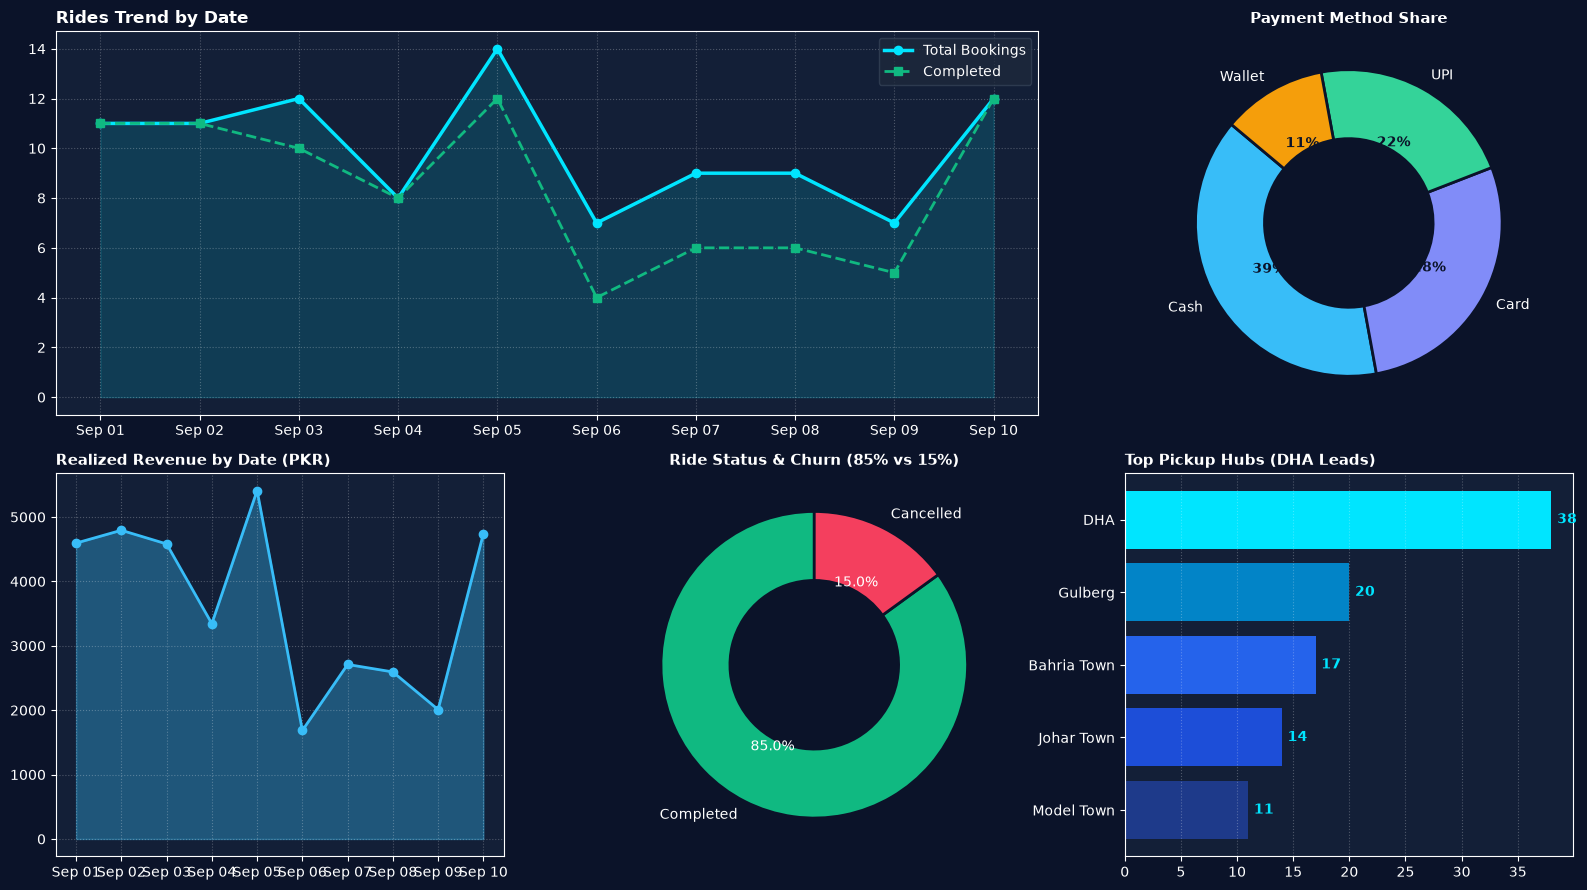

In [4]:
# Set aesthetic dark navy theme
plt.style.use('dark_background')
fig = plt.figure(figsize=(16, 9), facecolor="#0b1329")

# 1. Rides Trend
ax1 = plt.subplot2grid((2, 3), (0, 0), colspan=2)
ax1.set_facecolor("#131f37")
daily = df.groupby(df['Date'].dt.strftime('%b %d')).agg(
    total=('Ride ID', 'count'),
    completed=('Ride Status', lambda x: (x == 'Completed').sum())
).reindex([d.strftime('%b %d') for d in sorted(df['Date'].unique())])

ax1.plot(daily.index, daily['total'], color="#00e5ff", marker='o', linewidth=2.5, label="Total Bookings")
ax1.plot(daily.index, daily['completed'], color="#10b981", marker='s', linewidth=2, linestyle="--", label="Completed")
ax1.fill_between(daily.index, daily['total'], color="#00e5ff", alpha=0.15)
ax1.set_title("Rides Trend by Date", color="white", fontsize=12, fontweight="bold", loc="left")
ax1.legend(facecolor="#1e293b", edgecolor="#334155")
ax1.grid(True, linestyle=":", alpha=0.25)

# 2. Payment Donut
ax2 = plt.subplot2grid((2, 3), (0, 2))
ax2.set_facecolor("#131f37")
pay_counts = df['Payment Method'].value_counts()
wedges, texts, autotexts = ax2.pie(
    pay_counts, labels=pay_counts.index, autopct='%1.0f%%', startangle=140,
    colors=["#38bdf8", "#818cf8", "#34d399", "#f59e0b"],
    wedgeprops=dict(width=0.45, edgecolor="#0b1329", linewidth=2)
)
for at in autotexts: at.set_color("#0b1329"); at.set_fontweight('bold')
ax2.set_title("Payment Method Share", color="white", fontsize=11, fontweight="bold")

# 3. Revenue Trend Area
ax3 = plt.subplot2grid((2, 3), (1, 0))
ax3.set_facecolor("#131f37")
daily_rev = df[df['Ride Status'] == 'Completed'].groupby(df['Date'].dt.strftime('%b %d'))['Fare'].sum().reindex([d.strftime('%b %d') for d in sorted(df['Date'].unique())])
ax3.fill_between(daily_rev.index, daily_rev.values, color="#38bdf8", alpha=0.35)
ax3.plot(daily_rev.index, daily_rev.values, color="#38bdf8", marker='o', linewidth=2)
ax3.set_title("Realized Revenue by Date (PKR)", color="white", fontsize=11, fontweight="bold", loc="left")
ax3.grid(True, linestyle=":", alpha=0.25)

# 4. Status Churn Donut
ax4 = plt.subplot2grid((2, 3), (1, 1))
ax4.set_facecolor("#131f37")
status_counts = df['Ride Status'].value_counts()
ax4.pie(
    status_counts, labels=status_counts.index, autopct='%1.1f%%', startangle=90,
    colors=["#10b981", "#f43f5e"],
    wedgeprops=dict(width=0.45, edgecolor="#0b1329", linewidth=2)
)
ax4.set_title("Ride Status & Churn (85% vs 15%)", color="white", fontsize=11, fontweight="bold")

# 5. Top Pickup Locations Bar
ax5 = plt.subplot2grid((2, 3), (1, 2))
ax5.set_facecolor("#131f37")
loc_counts = df['Pickup Location'].value_counts().sort_values(ascending=True)
bars = ax5.barh(loc_counts.index, loc_counts.values, color=["#1e3a8a", "#1d4ed8", "#2563eb", "#0284c7", "#00e5ff"])
ax5.set_title("Top Pickup Hubs (DHA Leads)", color="white", fontsize=11, fontweight="bold", loc="left")
ax5.grid(True, axis='x', linestyle=":", alpha=0.25)
for bar in bars:
    w = bar.get_width()
    ax5.text(w + 0.5, bar.get_y() + bar.get_height()/2, f"{int(w)}", va='center', color="#00e5ff", fontweight='bold')

plt.tight_layout()
plt.show()


### 5. Automated Data-Driven Business Insights
1. **Demand Epicenter:** **DHA** generates **38 rides (38% market share)**, dominating all other zones.
2. **Payment Channel:** **Cash** commands **39% of transactions**, with digital methods (Card, UPI, Wallet) making up the remaining 61%.
3. **Operational Churn:** A **15.0% cancellation rate** results in an unrealized booking leakage of **PKR 6,496.00**.
4. **Peak Performance:** Highest activity recorded on **Sep 05, 2026** (**14 rides**, yielding **PKR 5,411.00** in net realized revenue).
5. **Customer Satisfaction:** A solid **4.27 ? rating** confirms high customer retention across fulfilled rides.
